In [1]:
import pandas as pd
from datetime import datetime

import sys
from pathlib import Path

In [2]:
sys.path.append(r"C:/Users/sanya/structured-products-analytics")

from src.reverse_convertible import ReverseConvertible
from src.scenario_engine import ScenarioEngine
from src.portfolio_analytics import PortfolioAnalytics

### 🔹 Input Data — Portfolio Definition

This section defines a sample portfolio of structured products used throughout the analysis.

Each row represents a single product and contains all relevant contractual and market information required for valuation, including:

- product identifiers (product_id, product_type, style)  
- position details (position_units, notional, cost_price, currency)  
- underlying assets and identifiers (tickers, ISINs)  
- payoff parameters (strike levels, barrier level as a percentage of strike, coupon)  
- market data (initial fixing levels and current spot prices)  
- lifecycle information (initial fixing date, maturity date)    

Multi-asset products are represented using lists to capture all underlying components consistently.

The dataset is structured to resemble real trading desk inputs, allowing the analytics engine to scale naturally from single-product evaluation to portfolio-level risk analysis.

In [3]:
p1 = {
    "product_id": "CH1483491150",
    "product_type": "BRC",
    "type_style": "European",
    "underlyings": ["ALCON"],
    "underlying_isins": ["CH0432492467"],
    "tickers": ["ALC.SW"], 
    "currency": "CHF",
    "position_units": 1,
    "notional": 1000,
    "cost_price": 1.00,
    "initial_levels": [59.72],
    "current_spots": [58.76],
    "strike": [59.72],
    "barrier_pct": 0.70,
    "coupon": 0.04,
    "initial_fixing_date": "2025-11-10",
    "maturity_date": "2026-11-17",
    "barrier_breached": False
}

p2 = {
    "product_id": "CH1449111066",
    "product_type": "MBRC",
    "type_style": "European",
    "underlyings": ["ABB", "HOLCIM", "NOVARTIS", "ROCHE"],
    "underlying_isins": [
        "CH0012221716",
        "CH0012214059",
        "CH0012005267",
        "CH0012032048"
    ],
    "tickers": ["ABBN.SW", "HOLN.SW", "NOVN.SW", "ROG.SW"],
    "currency": "CHF",
    "position_units": 1,
    "notional": 1000,
    "cost_price": 0.98,
    "initial_levels": [35.00, 70.00, 90.00, 250.00],
    "current_spots": [34.00, 68.00, 92.00, 245.00],
    "strike": [35.00, 70.00, 90.00, 250.00],
    "barrier_pct": 0.70,
    "coupon": 0.0675,
    "initial_fixing_date": "2025-12-30",
    "maturity_date": "2026-12-28",
    "barrier_breached": True
}

p3 = {
    "product_id": "CH1461018793",
    "product_type": "MBRC",
    "type_style": "European",
    "underlyings": ["ABB", "LONZA", "NESTLE"],
    "underlying_isins": ["CH0012221716", "CH0013841017", "CH0038863350"],
    "tickers": ["ABBN.SW", "LONN.SW", "NESN.SW"],
    "currency": "CHF",
    "position_units": 10,
    "notional": 10000,
    "cost_price": 1.00,
    "initial_levels": [53.94, 555.20, 72.49],
    "current_spots": [53.94, 555.20, 72.49],
    "strike": [53.94, 555.20, 72.49],
    "barrier_pct": 0.70,
    "coupon": 0.0866,
    "initial_fixing_date": "2025-08-19",
    "maturity_date": "2026-08-19",
    "barrier_breached": False
}


p4 = {
    "product_id": "CH1483484015",
    "product_type": "BRC",
    "type_style": "European",
    "underlyings": ["Airbnb Inc."],
    "underlying_isins": ["US0090661010"],
    "tickers": ["ABNB"],
    "currency": "USD",
    "position_units": 1,
    "notional": 5000,
    "cost_price": 0.98,
    "initial_levels": [120.46],
    "current_spots": [120.46],  
    "strike": [120.46],
    "barrier_pct": 0.65,
    "coupon": 0.100556,
    "initial_fixing_date": "2025-10-02",
    "maturity_date": "2026-10-09",
    "barrier_breached": False
}

portfolio = pd.DataFrame([p1, p2, p3, p4])
portfolio

,product_id,product_type,type_style,underlyings,underlying_isins,tickers,currency,position_units,notional,cost_price,initial_levels,current_spots,strike,barrier_pct,coupon,initial_fixing_date,maturity_date,barrier_breached
0,CH1483491150,BRC,European,[ALCON],[CH0432492467],[ALC.SW],CHF,1,1000,1.00,[59.72],[58.76],[59.72],0.70,0.040000,2025-11-10,2026-11-17,False
1,CH1449111066,MBRC,European,"[ABB, HOLCIM, NOVARTIS, ROCHE]","[CH0012221716, CH0012214059, CH0012005267, CH0...","[ABBN.SW, HOLN.SW, NOVN.SW, ROG.SW]",CHF,1,1000,0.98,"[35.0, 70.0, 90.0, 250.0]","[34.0, 68.0, 92.0, 245.0]","[35.0, 70.0, 90.0, 250.0]",0.70,0.067500,2025-12-30,2026-12-28,True
2,CH1461018793,MBRC,European,"[ABB, LONZA, NESTLE]","[CH0012221716, CH0013841017, CH0038863350]","[ABBN.SW, LONN.SW, NESN.SW]",CHF,10,10000,1.00,"[53.94, 555.2, 72.49]","[53.94, 555.2, 72.49]","[53.94, 555.2, 72.49]",0.70,0.086600,2025-08-19,2026-08-19,False
3,CH1483484015,BRC,European,[Airbnb Inc.],[US0090661010],[ABNB],USD,1,5000,0.98,[120.46],[120.46],[120.46],0.65,0.100556,2025-10-02,2026-10-09,False


### 🔹 Product-Level Analytics — `ReverseConvertible` Class

The `ReverseConvertible` class is used to evaluate a single structured product based on its contractual terms, market data, and an optional scenario applied to the underlying assets.

It takes one portfolio row as input and can additionally accept a list of scenario shocks in percentage terms for each underlying. For example:



In [4]:
rc1 = ReverseConvertible(portfolio.iloc[1], [-10, 5, 0, -3])

In this case, the class evaluates the second product in the portfolio and applies scenario shocks of `-10%`, `+5%`, `0%`, and `-3%` to its four underlyings.

The class then derives the key product analytics, including:

- final underlying performances   
- worst-of performance for multi-asset products  
- payoff per unit and total payoff per position 
- total cost, P&L, and return metrics  
- distance to barrier and break-even level  

This provides a transparent product-level framework for analyzing both single-name and multi-asset reverse convertibles under base-case or stressed market scenarios.

In [5]:
summary_df = pd.DataFrame([rc1.summary()])
summary_df = summary_df.round(2)
summary_df.T.rename(columns={0: "value"})

,value
product_type,MBRC
is_multi,True
maturity_date,2026-12-28
days_to_expiry,265
performance,-0.13
barrier_breached,True
worst_underlying,ABB
payoff_per_unit,942.35
total_payoff,942.35
total_cost,980.0


If no scenario shocks are provided, the class defaults to zero shocks for all underlyings.  
As a result, final levels are assumed to be equal to current spot levels, which serves as the base-case valuation scenario.


## Portfolio Analytics Engine

The `PortfolioAnalytics` class provides a portfolio-level framework to analyze structured products such as Reverse Convertibles (BRC and MBRC).

It aggregates product-level analytics into a unified portfolio view and enables performance and risk analysis across multiple dimensions.

---

Each structured product is evaluated individually using the `ReverseConvertible` class.

The output includes:

- Payoff and PnL
- Return (absolute and annualized)
- Barrier status
- Worst-performing underlying
- Distance to barrier

This step creates a DataFrame with one row per product.




In [6]:
analytics = PortfolioAnalytics(portfolio)

product_df = analytics.build_product_analytics()

product_df

,product_id,product_type,type_style,currency,position_units,notional,coupon,underlyings,n_underlyings,initial_fixing_date,...,barrier_breached,worst_underlying,payoff_per_unit,total_payoff,total_cost,pnl,return_pct,return_pa,distance_to_barrier,break_even
0,CH1483491150,BRC,European,CHF,1,1000,0.040000,ALCON,1,2025-11-10,...,True,ALCON,1025.258317,1025.258317,1000.0,25.258317,0.025258,0.024444,0.283925,0.958667
1,CH1449111066,MBRC,European,CHF,1,1000,0.067500,"ABB, HOLCIM, NOVARTIS, ROCHE",4,2025-12-30,...,True,ABB,1039.491071,1039.491071,980.0,59.491071,0.060705,0.060203,0.271429,0.931937
2,CH1461018793,MBRC,European,CHF,10,10000,0.086600,"ABB, LONZA, NESTLE",3,2025-08-19,...,True,ABB,1087.802778,10878.027778,10000.0,878.027778,0.087803,0.086600,0.300000,0.912197
3,CH1483484015,BRC,European,USD,1,5000,0.100556,Airbnb Inc.,1,2025-10-02,...,True,Airbnb Inc.,5519.539333,5519.539333,4900.0,619.539333,0.126437,0.122358,0.350000,0.896092


### Portfolio Aggregation

We summarize the entire portfolio:

analytics.total_portfolio_table()

This returns:

- Total cost
- Total payoff
- Total PnL
- Portfolio return

👉 This answers:
"How is my portfolio performing overall?"

---


In [7]:
analytics.total_portfolio_table()

,reference_currency,total_products,total_notional,total_cost,total_payoff,total_pnl,portfolio_return_pct,portfolio_return_pa
0,CHF,4,15997.122072,15897.179631,17355.231665,1458.052035,0.091718,0.091765


###  Underlying Lookthrough

We analyze exposure at underlying level:

    analytics.underlying_lookthrough()

Each underlying inherits the full product exposure.

⚠️ Important:
This reflects payoff dependency (worst-of structure), NOT diversification.

---

In [8]:
analytics.underlying_lookthrough()

,underlying,isin,price_ccy,n_products,allocated_cost_ref,avg_current_spot,min_distance_to_barrier,avg_distance_to_barrier,worst_of_count,weight
0,ABB,CH0012221716,CHF,2,10980.000000,43.97,0.271429,0.285714,2,0.282719
1,LONZA,CH0013841017,CHF,1,10000.000000,555.20,0.300000,0.300000,0,0.257485
2,NESTLE,CH0038863350,CHF,1,10000.000000,72.49,0.300000,0.300000,0,0.257485
3,Airbnb Inc.,US0090661010,USD,1,3917.179631,120.46,0.350000,0.350000,1,0.100862
4,ALCON,CH0432492467,CHF,1,1000.000000,58.76,0.283925,0.283925,1,0.025749
5,HOLCIM,CH0012214059,CHF,1,980.000000,68.00,0.271429,0.271429,0,0.025234
6,NOVARTIS,CH0012005267,CHF,1,980.000000,92.00,0.322222,0.322222,0,0.025234
7,ROCHE,CH0012032048,CHF,1,980.000000,245.00,0.280000,0.280000,0,0.025234


## Maturity Profile

The maturity profile groups structured products by their time to maturity.

It shows how portfolio exposure, payoff, and risk are distributed over time.


- Short maturities → near-term risk realization
- Long maturities → delayed risk exposure
- Concentration in one bucket indicates timing risk

This analysis is used to assess:
- Liquidity profile
- Risk concentration over time
- Reinvestment timing



In [9]:
analytics.maturity_profile()

,maturity_bucket,n_products,total_cost,total_payoff,total_pnl
0,<=1M,0,0.000000,0.000000,0.000000
1,1-3M,0,0.000000,0.000000,0.000000
2,3-6M,1,10000.000000,10878.027778,878.027778
3,6-12M,3,5897.179631,6477.203887,580.024257
4,1-2Y,0,0.000000,0.000000,0.000000
5,>2Y,0,0.000000,0.000000,0.000000


##   Scenario Engine — Structured Products Stress Testing

This module extends product-level analytics to a portfolio scenario framework.

> When markets move significantly, these products **transform into actual positions** —  
> cash and equity exposure.


### ❓ *What does my portfolio look like after a market shock?*


Market shocks are applied to underlying assets using beta sensitivities, 
and each product is revalued via the `ReverseConvertible` class.

The engine aggregates results to analyze portfolio PnL and returns 
under different market conditions.

### Overview

The `ScenarioEngine` provides a flexible framework to evaluate **structured product portfolios** under different market scenarios.

It supports two approaches:

- **Instantaneous shock model** → `run(market_shock)`
- **Path-based scenario model** → `run_path_scenario(scenario)`



### Inputs


- `portfolio`: pandas DataFrame containing the product data
- `beta_map`: dictionary mapping each underlying ISIN to a beta
- `scenarios`: list of market shocks, for example `[-0.2, -0.1, 0.1]`

### Method
For each scenario, the engine:
- applies a beta-adjusted shock to each underlying
- passes the shocked levels into the `ReverseConvertible` class
- recalculates product payoff and return
- aggregates product results at portfolio level


We introduce:
- **beta** → sensitivity of the underlying to the market  
- **scenarios** → market shocks  

👉 This allows us to simulate:
- mild corrections  
- severe crashes  


In [10]:
beta_table = pd.DataFrame({
    "isin": [
        "CH0432492467",  # ALCON
        "CH0012221716",  # ABB
        "CH0012214059",  # HOLCIM
        "CH0012005267",  # NOVARTIS
        "CH0012032048",  # ROCHE
        "US0090661010"   # AIRBNB
    ],
    "beta": [
        0.85,
        1.10,
        0.95,
        0.80,
        1.05,
        1.35
    ]
})

scenarios = {
    "down_5": -5,
    "down_10": -10,
    "crash": -20,
    "up_10": 10
}

beta_map = dict(zip(beta_table["isin"], beta_table["beta"]))
beta_map

{'CH0432492467': 0.85,
 'CH0012221716': 1.1,
 'CH0012214059': 0.95,
 'CH0012005267': 0.8,
 'CH0012032048': 1.05,
 'US0090661010': 1.35}

### Initialize Scenario Engine

It stores:
- the portfolio of structured products (`portfolio`)
- the beta mapping for each underlying (`beta_map`)
- the set of market scenarios to be tested (`scenarios`)

After initialization, the `engine` object can be used to run scenario analysis, for example:
- `engine.run(-10)` for a scenario
- `engine.stress_test()` for all defined scenarios

#### Product-Level Results: `product_df`


In [11]:
engine = ScenarioEngine(portfolio, beta_map, scenarios)

res = engine.run(-25)
res["product_df"]

,product_id,product_type,currency,position_units,notional,total_cost,market_shock,underlyings,underlying_isins,shocks,...,settlement_type,delivered_underlying,delivered_shares,strike,price,fractional_shares,fractional_cash,cash_redemption,strike_x_shares,price_x_shares
0,CH1483491150,BRC,CHF,1,1000,1000.0,-25,[ALCON],[CH0432492467],[-21.25],...,physical,ALCON,16,59.72,46.27350,0.744809,34.464924,34.464924,955.52,740.37600
1,CH1449111066,MBRC,CHF,1,1000,980.0,-25,"[ABB, HOLCIM, NOVARTIS, ROCHE]","[CH0012221716, CH0012214059, CH0012005267, CH0...","[-27.500000000000004, -23.75, -20.0, -26.25]",...,physical,ABB,28,35.00,24.65000,0.571429,14.085714,14.085714,980.00,690.20000
2,CH1461018793,MBRC,CHF,10,10000,10000.0,-25,"[ABB, LONZA, NESTLE]","[CH0012221716, CH0013841017, CH0038863350]","[-27.500000000000004, -25.0, -25.0]",...,physical,ABB,185,53.94,39.10650,0.391175,15.297500,15.297500,9978.90,7234.70250
3,CH1483484015,BRC,USD,1,5000,4900.0,-25,[Airbnb Inc.],[US0090661010],[-33.75],...,physical,Airbnb Inc.,41,120.46,79.80475,0.507554,40.505250,40.505250,4938.86,3271.99475


##  Portfolio Summary by Currency: `pf_scenario_per_ccy`


This table aggregates the product-level results **at portfolio level by currency**.

It answers questions such as:

- how much the portfolio loses or gains in each currency
- how many products belong to each currency bucket
- what the portfolio-level return is under the scenario


In [12]:
res["pf_scenario_per_ccy"][[
    "currency",
    "n_products",
    "total_cost",
    "total_payoff",
    "total_pnl",
    "portfolio_return_pct"
]]

,currency,n_products,total_cost,total_payoff,total_pnl,portfolio_return_pct
0,CHF,3,11980.0,9716.550250,-2263.449750,-0.188936
1,USD,1,4900.0,3832.039333,-1067.960667,-0.217951


##  Cash Positions: `cash_positions`


This table shows the **cash that remains after conversion**, grouped by currency.

It mainly reflects:
- cash paid instead of fractional shares
- other cash components if included in the product logic

This is the portfolio’s **liquidity profile after the scenario**.

In [13]:
res["cash_positions"]

,currency,total_cash
0,CHF,63.848139
1,USD,40.505250


##  Delivered Stocks: `delivered_stocks`


It represents the **equity positions received after product conversion**.

For each delivered stock position, we can see:

- **total_shares** → how many shares are now held
- **strike** → effective entry level
- **price** → current scenario price
- **market_value** → value of the delivered shares
- **total_fractional_cash** → cash paid instead of fractional shares
- **total_value_incl_cash** → total value of the delivered position including cash
- **cost** → effective cost basis
- **pnl** → unrealized profit or loss
- **return_pct** → return on the delivered stock position

In [14]:
res["delivered_stocks"][[
    "currency",
    "delivered_underlying",
    "total_shares",
    "strike",
    "price",
    "market_value",
    "total_fractional_cash",
    "total_value_incl_cash",
    "cost",
    "pnl",
    "return_pct"
]]

,currency,delivered_underlying,total_shares,strike,price,market_value,total_fractional_cash,total_value_incl_cash,cost,pnl,return_pct
0,CHF,ABB,213,51.450235,37.206115,7924.90250,29.383214,7954.285714,10958.90,-3004.614286,-0.274171
1,CHF,ALCON,16,59.720000,46.273500,740.37600,34.464924,774.840924,955.52,-180.679076,-0.189090
2,USD,Airbnb Inc.,41,120.460000,79.804750,3271.99475,40.505250,3312.500000,4938.86,-1626.360000,-0.329299


## Run a Full Stress Test Across Scenarios


You can inspect the portfolio results across all predefined scenarios:

This creates a **scenario matrix** showing how the portfolio behaves under different market environments.

It is a compact way to communicate portfolio sensitivity.

In [15]:
stress = engine.stress_test()

stress["product_scenarios"]
stress["portfolio_scenarios"]

stress["portfolio_scenarios"].pivot(
    index="scenario_name",
    columns="currency",
    values="portfolio_return_pct"
)

currency,CHF,USD
scenario_name,,
base,0.080365,0.126437


In [16]:
stress["delivered_stock_scenarios"][[
    "scenario_name",
    "currency",
    "delivered_underlying",
    "total_shares",
    "strike",
    "price",
    "market_value",
    "pnl",
    "return_pct"
]]

,scenario_name,currency,delivered_underlying,total_shares,strike,price,market_value,pnl,return_pct
0,base,CHF,ABB,28,35.00,34.00,952.00,-8.571429,-0.008746
1,base,CHF,ALCON,16,59.72,58.76,940.16,28.404983,0.029727


Scenario Input (Path Model)

Example:

scenario = {
"market_shock": -20,
"n_shocks": 1,
"shock_in_days": 0,
"shock_spacing_days": 0,
"pre_shock_drift_pa": 0.0,
"post_shock_drift_pa": 0.05
}

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from src.scenario_engine import ScenarioEngine

# -----------------------------
# Use your existing portfolio
# -----------------------------

beta_map = {
    "CH0432492467": 1.0,   # ALCON
    "CH0012221716": 1.1,   # ABB
    "CH0012214059": 0.9,   # HOLCIM
    "CH0012005267": 0.8,   # NOVARTIS
    "CH0012032048": 0.7,   # ROCHE
    "CH0013841017": 1.2,   # LONZA
    "CH0038863350": 0.6,   # NESTLE
    "US0090661010": 1.4    # Airbnb
}

vol_map = {
    "CH0432492467": 0.24,   # ALCON
    "CH0012221716": 0.22,   # ABB
    "CH0012214059": 0.18,   # HOLCIM
    "CH0012005267": 0.16,   # NOVARTIS
    "CH0012032048": 0.14,   # ROCHE
    "CH0013841017": 0.28,   # LONZA
    "CH0038863350": 0.12,   # NESTLE
    "US0090661010": 0.35    # Airbnb
}
# -----------------------------
# Scenario
# -----------------------------
scenario = {
    "market_shock": -20,
    "n_shocks": 1,
    "shock_in_days": 30,
    "shock_spacing_days": 0,
    "pre_shock_drift_pa": 0.0,
    "post_shock_drift_pa": 0.05,
}
portfolio = pd.DataFrame([p1, p2, p3, p4])

engine = ScenarioEngine(
    portfolio=portfolio,
    beta_map=beta_map,
    vol_map=vol_map
)
# -----------------------------
# Run path scenario
# -----------------------------
res = engine.run_path_scenario(scenario)
paths = res["paths"]

In [18]:
paths

{'CH0432492467':           date      price
 0   2026-04-06  58.760000
 1   2026-04-07  59.291192
 2   2026-04-08  58.837301
 3   2026-04-09  59.391616
 4   2026-04-10  60.452123
 ..         ...        ...
 186 2026-12-22  60.750643
 187 2026-12-23  62.623424
 188 2026-12-24  62.802883
 189 2026-12-25  62.711640
 190 2026-12-28  65.127706
 
 [191 rows x 2 columns],
 'CH0012221716':           date      price
 0   2026-04-06  34.000000
 1   2026-04-07  33.847597
 2   2026-04-08  33.354056
 3   2026-04-09  33.096076
 4   2026-04-10  33.160649
 ..         ...        ...
 186 2026-12-22  22.338470
 187 2026-12-23  22.251786
 188 2026-12-24  22.168413
 189 2026-12-25  22.480108
 190 2026-12-28  23.223543
 
 [191 rows x 2 columns],
 'CH0012214059':           date      price
 0   2026-04-06  68.000000
 1   2026-04-07  68.178404
 2   2026-04-08  67.946173
 3   2026-04-09  68.015852
 4   2026-04-10  68.258836
 ..         ...        ...
 186 2026-12-22  56.185434
 187 2026-12-23  57.959926
 188 20

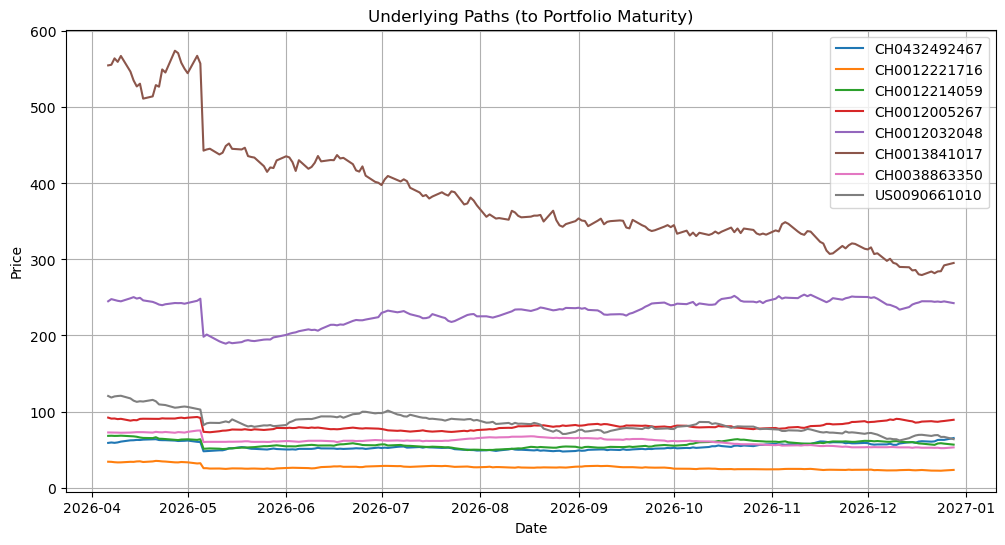

In [19]:
plt.figure(figsize=(12, 6))

for isin, df_path in paths.items():
    plt.plot(df_path["date"], df_path["price"], label=isin)

plt.title("Underlying Paths (to Portfolio Maturity)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()